# CREAM Progressive Graph Noise

Loads progressive graph-noise runs and plots task accuracy, concept accuracy, CCI, PFI, and intervention curves as a function of graph distance.

In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 160)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'experiments').exists() and (PROJECT_ROOT.parent / 'experiments').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

dataset_roots = {
    'cub': PROJECT_ROOT / 'experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise',
    'celeba': PROJECT_ROOT / 'experiments/CelebA/train_cbm/Standard_CelebA/celeba_progressive_noise/CREAM_celeba_progressive_noise',
}
metadata_paths = {
    'cub': PROJECT_ROOT / 'data/CUB/progressive_noise_graph/progressive_noise_metadata.csv',
    'celeba': PROJECT_ROOT / 'data/CelebA/progressive_noise_graph/progressive_noise_metadata.csv',
}
summary_out = PROJECT_ROOT / 'notebook/progressive_noise_summary_values.csv'
intervention_out = PROJECT_ROOT / 'notebook/progressive_noise_intervention_values.csv'

def load_last_metrics(dataset_roots, metadata_paths):
    rows = []
    for dataset, root in dataset_roots.items():
        for csv_path in sorted(root.glob('noise_*/last_metrics/*.csv')):
            df = pd.read_csv(csv_path)
            if df.empty:
                continue
            row = df.iloc[0].to_dict()
            row['dataset'] = dataset
            row['noise_percent'] = int(csv_path.relative_to(root).parts[0].replace('noise_', ''))
            row['csv_path'] = str(csv_path)
            rows.append(row)
    results = pd.DataFrame(rows)
    metadata_rows = []
    for dataset, path in metadata_paths.items():
        if path.exists():
            meta = pd.read_csv(path)
            if 'dataset' not in meta.columns:
                meta['dataset'] = dataset
            metadata_rows.append(meta)
    metadata = pd.concat(metadata_rows, ignore_index=True) if metadata_rows else pd.DataFrame()
    if results.empty:
        return results
    if not metadata.empty:
        results = results.merge(metadata, on=['dataset', 'noise_percent'], how='left', suffixes=('', '_metadata'))
    if 'graph_distance' not in results.columns:
        results['graph_distance'] = results['noise_percent'] / 100.0
    return results.sort_values(['dataset', 'noise_percent'])

def load_interventions(dataset_roots, metadata_paths):
    rows = []
    for dataset, root in dataset_roots.items():
        for csv_path in sorted(root.glob('noise_*/lightning_logs/**/intervention_results.csv')):
            df = pd.read_csv(csv_path)
            if df.empty:
                continue
            df['dataset'] = dataset
            df['noise_percent'] = int(csv_path.relative_to(root).parts[0].replace('noise_', ''))
            df['csv_path'] = str(csv_path)
            rows.append(df)
    interventions = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    if interventions.empty:
        return interventions
    metadata_rows = []
    for dataset, path in metadata_paths.items():
        if path.exists():
            meta = pd.read_csv(path)
            if 'dataset' not in meta.columns:
                meta['dataset'] = dataset
            metadata_rows.append(meta)
    metadata = pd.concat(metadata_rows, ignore_index=True) if metadata_rows else pd.DataFrame()
    if not metadata.empty:
        interventions = interventions.merge(metadata, on=['dataset', 'noise_percent'], how='left', suffixes=('', '_metadata'))
    if 'graph_distance' not in interventions.columns:
        interventions['graph_distance'] = interventions['noise_percent'] / 100.0
    return interventions.sort_values(['dataset', 'noise_percent'])

def intervention_accuracy_column(df):
    for col in ['test_task_accuracy', 'task_accuracy', 'accuracy', 'test_acc']:
        if col in df.columns:
            return col
    matches = [col for col in df.columns if 'accuracy' in col.lower() or col.lower().endswith('_acc')]
    return matches[0] if matches else None

def available(columns, candidates):
    return [col for col in candidates if col and col in columns]


## Saved Values Table

In [5]:
merged = load_last_metrics(dataset_roots, metadata_paths)

value_cols = available(
    merged.columns,
    [
        'dataset', 'noise_percent', 'graph_distance',
        'num_flipped_positions', 'different_edges', 'added_edges', 'deleted_edges',
        'original_true_entries', 'perturbed_true_entries', 'perturbed_edges',
        'test_task_accuracy', 'test_concept_accuracy', 'test_dropout_task_accuracy',
        'CCI', 'PFI_concept_importance', 'PFI_side_importance',
        'csv_path',
    ],
)

if merged.empty:
    print('No progressive-noise result CSVs found yet. Run the progressive_noise Condor jobs first.')
else:
    summary_values = merged[value_cols].sort_values(['dataset', 'noise_percent'])
    summary_values.to_csv(summary_out, index=False)
    print(f'Saved summary values to {summary_out}')
    display(summary_values)


Saved summary values to /home/dani00003/mCREAM/notebook/progressive_noise_summary_values.csv


,dataset,noise_percent,graph_distance,different_edges,added_edges,deleted_edges,perturbed_edges,test_task_accuracy,test_concept_accuracy,test_dropout_task_accuracy,PFI_concept_importance,PFI_side_importance,csv_path
0,cub,10,0.099996,9734,6750,2984,33854,0.729375,0.868315,0.720419,6.953815e-01,0.014468,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_010/last_metrics/CREAM_cub_progressive...
1,cub,20,0.200002,19469,13510,5959,37639,0.730929,0.868013,0.720419,6.925820e-01,0.018050,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_020/last_metrics/CREAM_cub_progressive...
2,cub,30,0.299998,29203,20197,9006,41279,0.731964,0.866814,0.726178,6.894477e-01,0.016705,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_030/last_metrics/CREAM_cub_progressive...
3,cub,40,0.400004,38938,26937,12001,45024,0.730411,0.866444,0.719372,6.840542e-01,0.020718,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_040/last_metrics/CREAM_cub_progressive...
4,cub,50,0.500000,48672,33612,15060,48640,0.729030,0.864121,0.715707,6.721091e-01,0.026372,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_050/last_metrics/CREAM_cub_progressive...
5,cub,60,0.599996,58406,40410,17996,52502,0.729720,0.861795,0.704712,6.615206e-01,0.040618,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_060/last_metrics/CREAM_cub_progressive...
6,cub,70,0.700002,68141,47047,21094,56041,0.728857,0.860137,0.684468,6.306265e-01,0.068607,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_070/last_metrics/CREAM_cub_progressive...
7,cub,80,0.799998,77875,53769,24106,59751,0.710563,0.860128,0.612740,5.384674e-01,0.146652,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_080/last_metrics/CREAM_cub_progressive...
8,cub,90,0.900004,87610,60537,27073,63552,0.696410,0.865988,0.353927,3.479375e-01,0.396158,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_090/last_metrics/CREAM_cub_progressive...
9,cub,100,1.000000,97344,67256,30088,67256,0.717639,0.872174,0.005236,-2.701446e-08,0.712466,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_100/last_metrics/CREAM_cub_progressive...


In [10]:
merged

,max_epochs,seed,experiment_name,train_val_time,test_time,num_trainable_parameters,train_task_loss,train_task_accuracy,train_concept_loss,train_concept_accuracy,train_total_loss,train_task_loss_percent,lr-Adam,val_task_loss,val_task_accuracy,val_concept_loss,val_concept_accuracy,val_total_loss,val_task_loss_percent,test_task_loss,test_task_accuracy,test_concept_loss,test_concept_accuracy,test_total_loss,test_task_loss_percent,num_exogenous,num_classes,num_concepts,num_side_channel,learning_rate,lambda_weight,frozen_model1,concept_representation,x2u,u2c,causal_graph,masking_algorithm,num_hidden_layers_in_maskedmlp,previous_model_output_size,last_layer_mask,side_dropout,dropout_prob,mutually_exclusive_concepts,CPU_time_backprop_True,CPU_memory_backprop_True,GPU_time_backprop_True,GPU_memory_backprop_True,CPU_time_backprop_False,CPU_memory_backprop_False,GPU_time_backprop_False,GPU_memory_backprop_False,test_dropout_task_accuracy,PFI_concept_importance,PFI_side_importance,true_concepts_concept_grouped_importance,true_concepts_debugging_sage_metrics_concepts,true_concepts_debugging_sage_metrics_side_channel,intervention_results,dataset,noise_percent,csv_path,dag_path,different_edges,total_edge_positions,graph_distance,added_edges,deleted_edges,original_edges,perturbed_edges
0,300,42,CREAM_cub_progressive_noise/noise_010,400.686462,0.801339,426366,0.534765,0.933333,0.958918,0.875298,1.493683,35.801785,0.0001,1.093765,0.719533,1.165832,0.866884,2.259598,48.042583,1.037727,0.729375,1.150733,0.868315,2.188460,46.111717,648,200,112,200,0.0001,1,True,group_soft,Sequential,UtoY_model,"tensor([[ True, True, True, ..., False, False, False],\n [ True, True, True, ..., True, False, False],\n [ True, False, False, ..., Fa...",zuko,0,512,True,True,0.8,"[[0, 1, 2, 3], [4, 5, 6, 7, 8, 9], [10, 11, 12, 13, 14, 15], [16, 17, 18, 19, 20, 21, 22], [23, 24], [25, 26, 27, 28, 29, 30], [32, 33, 34, 35, 36], [37, 38...",1.649741,0.023756,0.041749,492.958496,1.578694,0.022284,0.022808,492.604004,0.720419,6.953815e-01,0.014468,NaN,NaN,NaN,"[{'group_interventions': True, 'num_interventions': 0, 'metrics': {'num_interventions': 0.0, 'test_task_loss': 1.0377272367477417, 'test_task_accuracy': 0.7...",cub,10,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_010/last_metrics/CREAM_cub_progressive...,./data/CUB/progressive_noise_graph/CUB_DAG_only_Gc_noise_010.csv,9734,97344,0.099996,6750,2984,30088,33854
1,300,42,CREAM_cub_progressive_noise/noise_020,214.588071,1.049878,426993,0.580840,0.900000,0.972973,0.877083,1.553813,37.381607,0.0001,1.088813,0.723706,1.165556,0.866258,2.254370,48.045368,1.046956,0.730929,1.157462,0.868013,2.204418,46.196350,648,200,112,200,0.0001,1,True,group_soft,Sequential,UtoY_model,"tensor([[ True, True, True, ..., True, False, False],\n [ True, True, True, ..., False, False, False],\n [ True, True, True, ..., Fa...",zuko,0,512,True,True,0.8,"[[0, 1, 2, 3], [4, 5, 6, 7, 8, 9], [10, 11, 12, 13, 14, 15], [16, 17, 18, 19, 20, 21, 22], [23, 24], [25, 26, 27, 28, 29, 30], [32, 33, 34, 35, 36], [37, 38...",0.942489,0.023756,0.026202,529.744629,0.926331,0.022284,0.010371,529.390137,0.720419,6.925820e-01,0.018050,NaN,NaN,NaN,"[{'group_interventions': True, 'num_interventions': 0, 'metrics': {'num_interventions': 0.0, 'test_task_loss': 1.046955943107605, 'test_task_accuracy': 0.73...",cub,20,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_020/last_metrics/CREAM_cub_progressive...,./data/CUB/progressive_noise_graph/CUB_DAG_only_Gc_noise_020.csv,19469,97344,0.200002,13510,5959,30088,37639
2,300,42,CREAM_cub_progressive_noise/noise_030,263.710259,3.272536,427530,0.666483,0.916667,0.987244,0.876786,1.653728,40.301888,0.0001,1.097773,0.710351,1.176234,0.865915,2.274007,47.986202,1.052328,0.731964,1.166951,0.866814,2.219279,46.112370,648,200,112,200,0.0001,1,True,group_soft,Sequential,UtoY_model,"tensor([[ True, T

## Accuracy, CCI, and PFI Curves

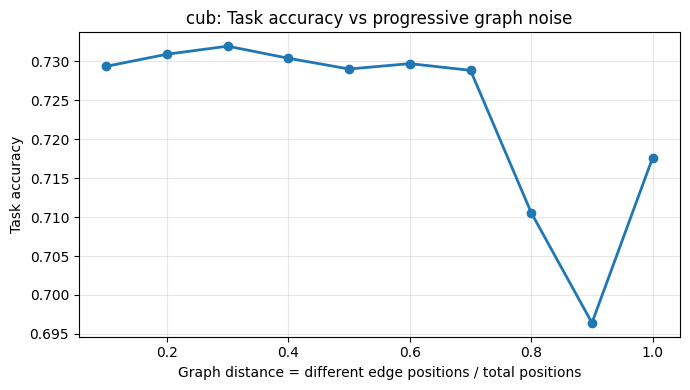

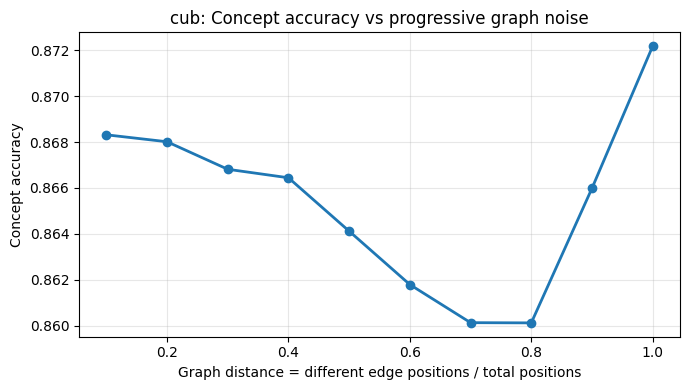

Skipping CCI: column not found in last_metrics.


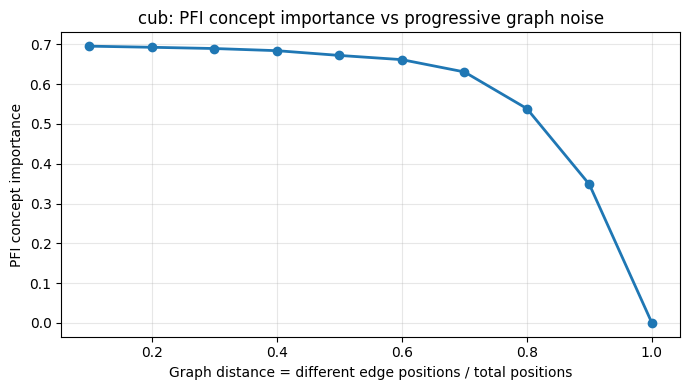

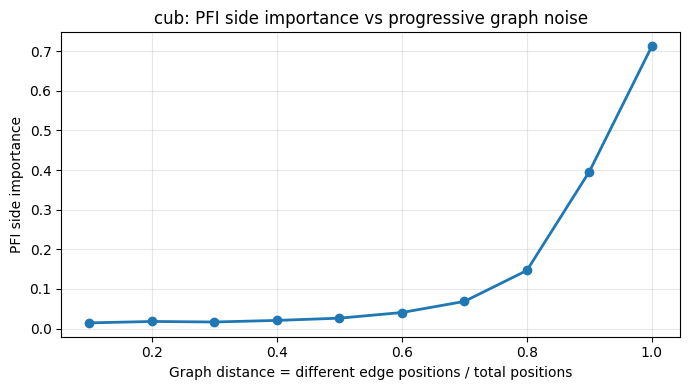

In [6]:
metrics_to_plot = [
    ('test_task_accuracy', 'Task accuracy'),
    ('test_concept_accuracy', 'Concept accuracy'),
    ('CCI', 'CCI'),
    ('PFI_concept_importance', 'PFI concept importance'),
    ('PFI_side_importance', 'PFI side importance'),
]

if merged.empty:
    print('No progressive-noise metrics available yet.')
else:
    x_col = 'graph_distance' if 'graph_distance' in merged.columns else 'noise_percent'
    for metric, label in metrics_to_plot:
        if metric not in merged.columns:
            print(f'Skipping {metric}: column not found in last_metrics.')
            continue
        for dataset, df in merged.groupby('dataset'):
            df = df.dropna(subset=[x_col, metric]).sort_values(x_col)
            if df.empty:
                continue
            fig, ax = plt.subplots(figsize=(7, 4))
            ax.plot(df[x_col], df[metric], marker='o', linewidth=2)
            ax.set_xlabel('Graph distance = different edge positions / total positions' if x_col == 'graph_distance' else 'Noise percent')
            ax.set_ylabel(label)
            ax.set_title(f'{dataset}: {label} vs progressive graph noise')
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()


## Combined Metric Curves

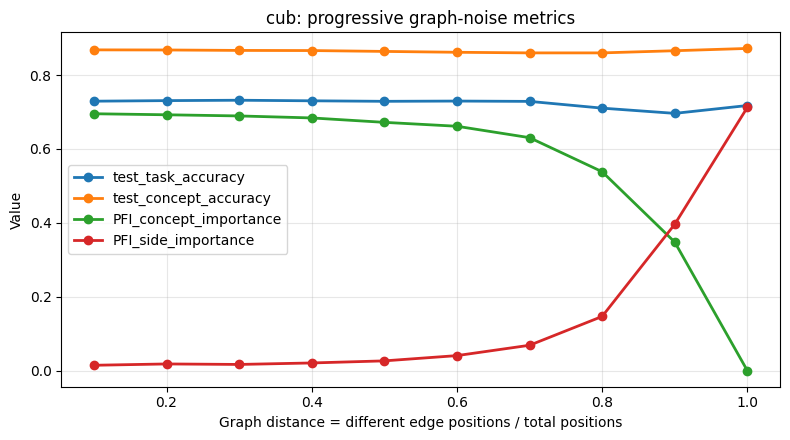

In [7]:
if merged.empty:
    print('No progressive-noise metrics available yet.')
else:
    x_col = 'graph_distance' if 'graph_distance' in merged.columns else 'noise_percent'
    for dataset, df in merged.groupby('dataset'):
        df = df.sort_values(x_col)
        plot_cols = [metric for metric, _ in metrics_to_plot if metric in df.columns and df[metric].notna().any()]
        if not plot_cols:
            print(f'No plottable metric columns for {dataset}.')
            continue
        fig, ax = plt.subplots(figsize=(8, 4.5))
        for metric in plot_cols:
            ax.plot(df[x_col], df[metric], marker='o', linewidth=2, label=metric)
        ax.set_xlabel('Graph distance = different edge positions / total positions' if x_col == 'graph_distance' else 'Noise percent')
        ax.set_ylabel('Value')
        ax.set_title(f'{dataset}: progressive graph-noise metrics')
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()


## Intervention Values and Curves

In [8]:
interventions = load_interventions(dataset_roots, metadata_paths)
acc_col = intervention_accuracy_column(interventions)

intervention_cols = available(
    interventions.columns,
    ['dataset', 'noise_percent', 'graph_distance', 'group_interventions', 'num_interventions', acc_col, 'csv_path'],
)

if interventions.empty:
    print('No intervention_results.csv files found yet. They are written under noise_*/lightning_logs/**/ after evaluation.')
else:
    intervention_values = interventions[intervention_cols].sort_values(['dataset', 'noise_percent', 'group_interventions', 'num_interventions'])
    intervention_values.to_csv(intervention_out, index=False)
    print(f'Saved intervention values to {intervention_out}')
    display(intervention_values)


Saved intervention values to /home/dani00003/mCREAM/notebook/progressive_noise_intervention_values.csv


,dataset,noise_percent,graph_distance,group_interventions,num_interventions,test_task_accuracy,csv_path
26,cub,10,0.099996,False,0.0,0.729375,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_010/lightning_logs/version_0/intervent...
27,cub,10,0.099996,False,1.0,0.732654,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_010/lightning_logs/version_0/intervent...
28,cub,10,0.099996,False,2.0,0.733517,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_010/lightning_logs/version_0/intervent...
29,cub,10,0.099996,False,3.0,0.737314,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_010/lightning_logs/version_0/intervent...
30,cub,10,0.099996,False,4.0,0.739558,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_010/lightning_logs/version_0/intervent...
...,...,...,...,...,...,...,...
1272,cub,100,1.000000,True,21.0,0.717639,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_100/lightning_logs/version_0/intervent...
1273,cub,100,1.000000,True,22.0,0.717639,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_100/lightning_logs/version_0/intervent...
1274,cub,100,1.000000,True,23.0,0.717639,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_100/lightning_logs/version_0/intervent...
1275,cub,100,1.000000,True,24.0,0.717639,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_100/lightning_logs/version_0/intervent...


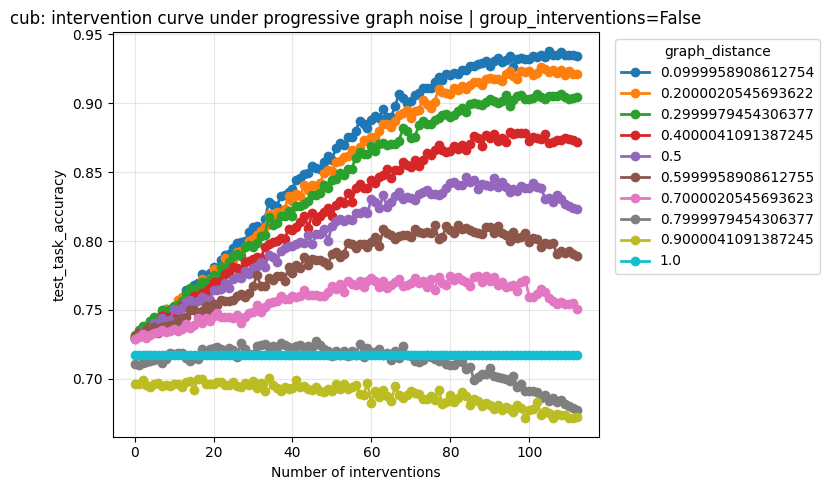

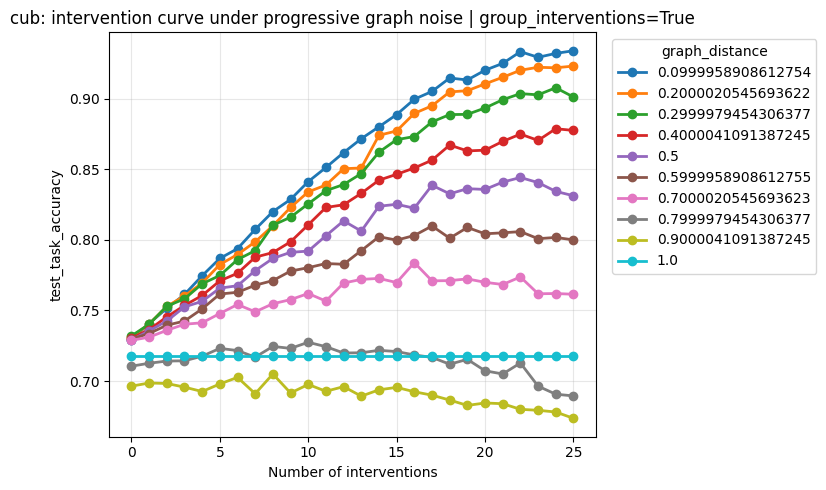

In [9]:
if interventions.empty or acc_col is None or 'num_interventions' not in interventions.columns:
    print('No plottable intervention curves yet.')
else:
    for dataset, dataset_df in interventions.groupby('dataset'):
        group_values = [None]
        if 'group_interventions' in dataset_df.columns:
            group_values = sorted(dataset_df['group_interventions'].dropna().unique())
        for group_value in group_values:
            df = dataset_df if group_value is None else dataset_df[dataset_df['group_interventions'] == group_value]
            if df.empty:
                continue
            hue_col = 'graph_distance' if 'graph_distance' in df.columns else 'noise_percent'
            fig, ax = plt.subplots(figsize=(8, 5))
            for hue_value, hue_df in df.groupby(hue_col):
                hue_df = hue_df.sort_values('num_interventions')
                ax.plot(hue_df['num_interventions'], hue_df[acc_col], marker='o', linewidth=2, label=str(hue_value))
            suffix = '' if group_value is None else f' | group_interventions={group_value}'
            ax.set_xlabel('Number of interventions')
            ax.set_ylabel(acc_col)
            ax.set_title(f'{dataset}: intervention curve under progressive graph noise{suffix}')
            ax.grid(True, alpha=0.3)
            ax.legend(title=hue_col, bbox_to_anchor=(1.02, 1), loc='upper left')
            plt.tight_layout()
            plt.show()
